In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [3]:
folder_path = "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs/20250710-183002"

In [ ]:
# Lists to collect values
image_means = []
image_maxs = []
hp_means = []
hp_maxs = []

# Load data from each results.json
for subdir in sorted(os.listdir(folder_path)):
    json_path = os.path.join(folder_path, subdir, "results.json")
    if os.path.isfile(json_path):
        with open(json_path, "r") as f:
            data = json.load(f)
        ir = data.get("ImageReward", {})
        hp = data.get("HumanPreference", {})
        image_means.append(ir.get("mean"))
        image_maxs.append(ir.get("max"))
        hp_means.append(hp.get("mean"))
        hp_maxs.append(hp.get("max"))

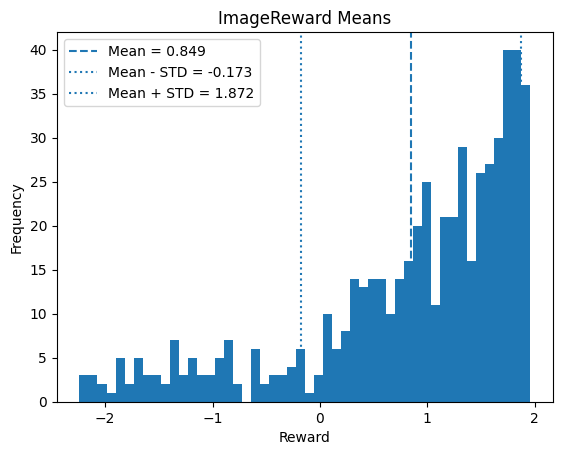

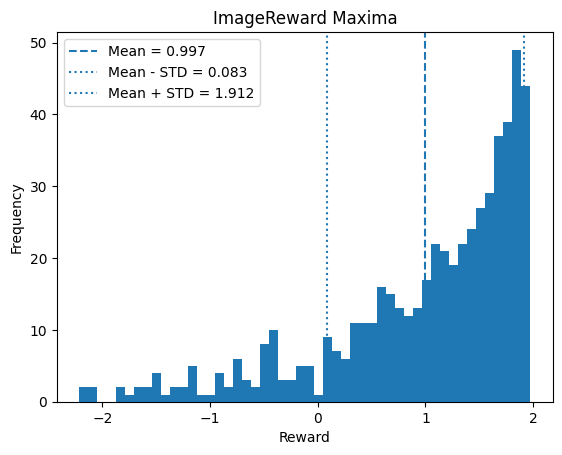

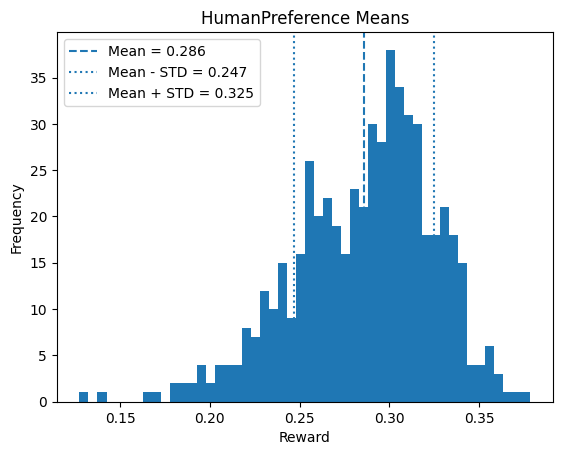

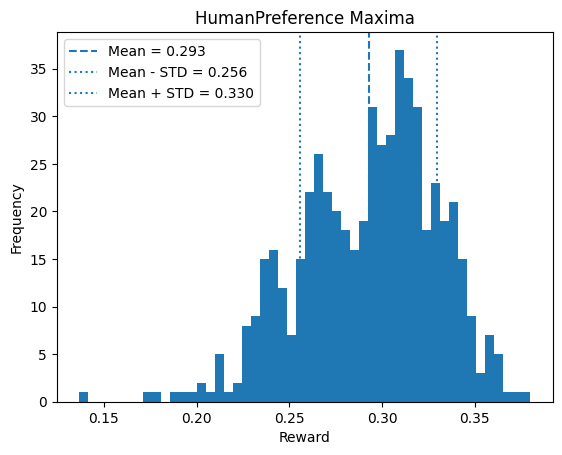

In [5]:
# Function to plot histogram with mean and std lines
def plot_hist(data, title):
    mean = np.mean(data)
    std = np.std(data)
    plt.figure()
    plt.hist(data, bins=50)
    plt.axvline(mean, linestyle='--', label=f"Mean = {mean:.3f}")
    plt.axvline(mean - std, linestyle=':', label=f"Mean - STD = {mean - std:.3f}")
    plt.axvline(mean + std, linestyle=':', label=f"Mean + STD = {mean + std:.3f}")
    plt.title(title)
    plt.xlabel("Reward")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Generate the four histograms
plot_hist(image_means, "ImageReward Means")
plot_hist(image_maxs, "ImageReward Maxima")
plot_hist(hp_means, "HumanPreference Means")
plot_hist(hp_maxs, "HumanPreference Maxima")

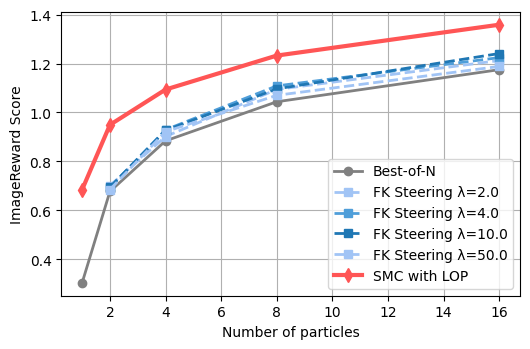

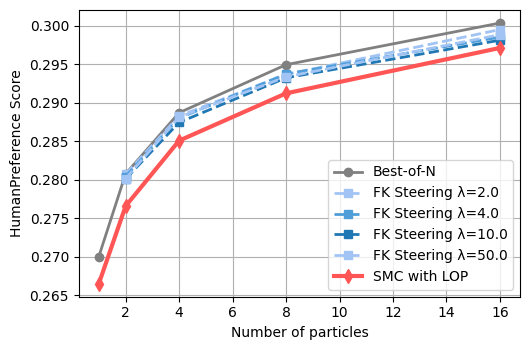

In [ ]:
# --- CONFIGURE YOUR ROOT FOLDERS HERE ---
root_folders = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs"
}

# Data accumulators
# For the first experiment we need smc flag and lambda
data1 = {True: {}, False: {}}  # data1[smc_flag][lambda][nparts] = list of metrics
# For the second experiment we store by kl_weight:
# data2[kl_weight][nparts] = list of metrics
data2 = {}

def _to_bool(v):
    """Robust conversion for boolean-like values in args.json"""
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)):
        return bool(v)
    if isinstance(v, str):
        return v.strip().lower() in ("1", "true", "yes", "y", "t")
    return False

def collect_first_experiment(root):
    for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse arguments
        nparts = int(args.get("num_particles"))

        smc = _to_bool(args.get("use_smc", False))
        lmbda = args.get("lmbda", None)
        lmbda = float(lmbda) if lmbda is not None else None

        data1[smc].setdefault(lmbda, {}).setdefault(nparts, [])

        # iterate samples in run folder
        for sample in sorted(os.listdir(run)):
            rj = os.path.join(run, sample, "results.json")
            if not os.path.isfile(rj):
                continue

            with open(rj, "r") as fh:
                R = json.load(fh)

            # expected keys
            ir = R["ImageReward"]["max"]
            hp = R["HumanPreference"]["max"]

            data1[smc][lmbda][nparts].append((ir, hp))

def collect_second_experiment(root):
    for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse num_particles
        nparts = int(args.get("num_particles"))

        # parse kl_weight (allow missing -> None)
        klw = args.get("kl_weight", None)
        klw = float(klw) if klw is not None else None

        data2.setdefault(klw, {}).setdefault(nparts, [])

        for sample in sorted(os.listdir(run)):
            rj = os.path.join(run, sample, "results.json")
            if not os.path.isfile(rj):
                continue

            with open(rj, "r") as fh:
                R = json.load(fh)

            ir = R["ImageReward"]["max"]
            hp = R["HumanPreference"]["max"]

            data2[klw][nparts].append((ir, hp))

def prepare_plot_data(particles_dict, idx):
    """
    particles_dict: {nparts: [(ir, hp), ...]}
    idx: 0 for IR, 1 for HP
    returns xs, ys where ys = mean of element idx
    """
    xs, ys = [], []
    for n in sorted(particles_dict.keys()):
        vals = [v[idx] for v in particles_dict[n] if v is not None]
        if len(vals) == 0:
            # skip particle counts with no samples
            continue
        xs.append(n)
        ys.append(float(np.mean(vals)))
    return xs, ys

def plot_metric(metric_label="IR", savepath="image_reward_comparison.pdf"):
    fig, ax = plt.subplots(figsize=(6*0.9,4*0.9))
    idx = 0 if metric_label == "IR" else 1

    # Best-of-N (SMC=False). They might have multiple lambda keys; pick first available
    bosn_lams = [k for k in data1[False].keys() if k is not None] or list(data1[False].keys())
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data(data1[False][lam0], idx)
        if xs:
            ax.plot(xs, ys, 'o-', lw=2, label="Best-of-N", color='gray')

    # SMC with varying λ from first experiment (if any)
    fk_colors = ['#a1c4f5', '#76aadf', '#4a91ca', '#1f77b4']
    for i, lam in enumerate(sorted([k for k in data1[True].keys() if k is not None])):
        xs, ys = prepare_plot_data(data1[True][lam], idx)
        if not xs:
            continue
        color = fk_colors[i % len(fk_colors)]
        ax.plot(xs, ys, 's--', lw=2, color=color, label=f"FK Steering λ={lam}")

    # SMC with LOP from second experiment (separate lines per kl_weight)
    # Use a Reds colormap to generate as many red shades as needed
    kl_weights = sorted(data2.keys(), key=lambda x: (x is None, x))  # keep None last if present
    n_kl = len(kl_weights)
    if n_kl > 0:
        colors = ['#ff0000', '#ff5555']
        for i, klw in enumerate(kl_weights):
            if klw == 0.01:
                continue
            xs, ys = prepare_plot_data(data2[klw], idx)
            if not xs:
                continue
            color = colors[i % len(colors)]
            # label = f"SMC LOP KL={klw}" if klw is not None else "SMC LOP KL=None"
            label = "SMC with LOP"
            ax.plot(xs, ys, marker='d', linestyle='-', linewidth=3, markersize=7,
                    markerfacecolor=color, color=color, label=label)

    ax.set_xlabel("Number of particles")
    ylabel = "ImageReward Score" if metric_label == "IR" else "HumanPreference Score"
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)
    fig.tight_layout()

    plt.show()

# --- MAIN ---
if __name__ == "__main__":
    collect_first_experiment(root_folders["SMC-steering"])
    collect_second_experiment(root_folders["SMC-Meissonic-LOP"])

    # change metric_label to "HP" if you'd like the HumanPreference plot
    plot_metric("IR")
    plot_metric("HP")

Summary of collected runs:
data1 smc=False lam=2.0: 5 runs across 5 particle settings
data1 smc=True lam=2.0: 4 runs across 4 particle settings
data1 smc=True lam=4.0: 4 runs across 4 particle settings
data1 smc=True lam=10.0: 4 runs across 4 particle settings
data1 smc=True lam=50.0: 4 runs across 4 particle settings
data2 kl_weight=0.01: 5 runs across 5 particle settings
data2 kl_weight=0.02: 5 runs across 5 particle settings


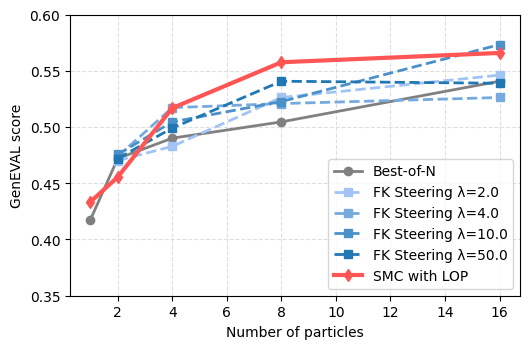

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# -- CONFIGURE YOUR ROOT FOLDERS HERE --
outputs_roots = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs"
}
# results_roots = {
#     "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_results",
#     "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_results"
# }
results_roots = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_results_best",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_results_best"
}

# Data accumulators for GenEVAL correct_images
# For the first experiment we need smc flag and lambda
data1 = {True: {}, False: {}}  # data1[smc_flag][lambda][nparts] = list of genEval_scores
# For the second experiment we now have multiple kl_weight settings:
# data2[kl_weight][nparts] = list of genEval_scores
data2 = {}  # dict keyed by kl_weight -> {nparts: [scores]}


def collect_first_experiment(outputs_root, results_root):
    """
    For each run_dir in outputs_root:
      - read args.json from outputs_root/run_dir/args.json
      - read results_root/run_dir/summary.json
      - extract 'correct_images' (fallback to 'overall_score')
      - append into data1[smc][lam][nparts]
    """
    for run_dir in sorted(os.listdir(outputs_root)):
        run_out = os.path.join(outputs_root, run_dir)
        if not os.path.isdir(run_out):
            continue
        argsf = os.path.join(run_out, "args.json")
        if not os.path.isfile(argsf):
            # no args.json -> skip
            continue
        try:
            with open(argsf, "r") as f:
                args = json.load(f)
        except Exception as e:
            print(f"failed to read args.json for {run_dir}: {e}")
            continue

        nparts = args.get("num_particles")
        smc = bool(args.get("use_smc"))
        lam_raw = args.get("lmbda", None)
        try:
            lam = float(lam_raw) if lam_raw is not None else None
        except Exception:
            lam = None

        # prepare data structure
        data1[smc].setdefault(lam, {}).setdefault(nparts, [])

        # Deterministic mapping to summary.json
        summary_path = os.path.join(results_root, run_dir, "summary.json")
        if not os.path.isfile(summary_path):
            # optionally warn
            # print(f"Missing summary.json for run {run_dir} in results_root")
            continue

        try:
            with open(summary_path, "r") as rf:
                R = json.load(rf)
            gen_eval_score = R.get("correct_images", R.get("overall_score"))
            if gen_eval_score is None:
                # nothing to append
                continue
            # ensure float
            gen_eval_score = float(gen_eval_score)
            data1[smc][lam][nparts].append(gen_eval_score)
        except Exception as e:
            print(f"failed to read/parse {summary_path}: {e}")


def collect_second_experiment(outputs_root, results_root):
    """
    For each run_dir in outputs_root:
      - read args.json from outputs_root/run_dir/args.json
      - read results_root/run_dir/summary.json
      - extract 'overall_score' (or 'correct_images' if you prefer)
      - append into data2[kl_weight][nparts]
    """
    for run_dir in sorted(os.listdir(outputs_root)):
        run_out = os.path.join(outputs_root, run_dir)
        if not os.path.isdir(run_out):
            continue
        argsf = os.path.join(run_out, "args.json")
        if not os.path.isfile(argsf):
            continue
        try:
            with open(argsf, "r") as f:
                args = json.load(f)
        except Exception as e:
            print(f"failed to read args.json for {run_dir}: {e}")
            continue

        nparts = args.get("num_particles")
        kl_raw = args.get("kl_weight", None)
        try:
            kl = float(kl_raw) if kl_raw is not None else None
        except Exception:
            kl = None

        # initialize nested dict
        data2.setdefault(kl, {}).setdefault(nparts, [])

        summary_path = os.path.join(results_root, run_dir, "summary.json")
        if not os.path.isfile(summary_path):
            # optionally warn
            # print(f"Missing summary.json for run {run_dir} in results_root")
            continue

        try:
            with open(summary_path, "r") as rf:
                R = json.load(rf)
            # use overall_score here (as your previous code did for data2)
            gen_eval_score = R.get("overall_score", R.get("correct_images"))
            if gen_eval_score is None:
                continue
            gen_eval_score = float(gen_eval_score)
            data2[kl][nparts].append(gen_eval_score)
        except Exception as e:
            print(f"failed to read/parse {summary_path}: {e}")


def prepare_plot_data_particles_dict(particles_dict):
    """
    particles_dict: {nparts: [score, ...]}
    returns xs, ys where ys = mean of scores for each nparts (sorted by nparts)
    """
    xs, ys = [], []
    for n in sorted(particles_dict):
        vals = particles_dict[n]
        if not vals:
            continue
        xs.append(n)
        ys.append(np.mean(vals))
    return xs, ys


def plot_geneval():
    fig, ax = plt.subplots(figsize=(6 * 0.9, 4 * 0.9))

    # Best-of-N (SMC=False). They share a lambda key, but pick whichever lam key exists
    bosn_lams = [k for k in data1[False].keys()]
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data_particles_dict(data1[False][lam0])
        if xs:
            ax.plot(xs, ys, 'o-', lw=2, label="Best-of-N", color='gray')

    # SMC with varying λ from first experiment
    lam_keys = [k for k in data1[True].keys() if k is not None]
    colors = ['#a1c4f5', '#4f9ed9', '#1f77b4']
    for i, lam in enumerate(sorted(lam_keys)):
        xs, ys = prepare_plot_data_particles_dict(data1[True][lam])
        if not xs:
            continue
        c = colors[i % len(colors)]
        ax.plot(xs, ys, 's--', lw=2, label=f"FK Steering λ={lam}", color=c)

    # SMC with LOP from second experiment (multiple kl_weight settings)
    kl_keys = sorted(data2.keys(), key=lambda x: (x is None, x))  # keep None last if present
    if kl_keys:
        # Use matplotlib Reds colormap to pick shades of red
        colors = ['#ff0000', '#ff5555']
        for i, kl in enumerate(kl_keys):
            if kl == 0.01:
                continue
            particles_dict = data2[kl]
            xs, ys = prepare_plot_data_particles_dict(particles_dict)
            if not xs:
                continue
            c = colors[i % len(colors)]
            # label = f"SMC LOP kl={kl}" if kl is not None else "SMC LOP (kl=None)"
            label = "SMC with LOP"
            ax.plot(xs, ys, 'd-', lw=3, markersize=6, markerfacecolor=c, label=label, color=c)

    ax.set_xlabel("Number of particles")
    ax.set_ylabel("GenEVAL score")
    # ax.set_ylim(0.0, 1.0)  # correct_images is a fraction -> set [0,1]
    ax.set_ylim(0.35, 0.60)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    return fig, ax


if __name__ == "__main__":
    # Collect data
    collect_first_experiment(outputs_roots["SMC-steering"], results_roots["SMC-steering"])
    collect_second_experiment(outputs_roots["SMC-Meissonic-LOP"], results_roots["SMC-Meissonic-LOP"])

    # Optional: print summary counts
    def summary_counts():
        print("Summary of collected runs:")
        for smc_flag in (False, True):
            for lam, d in data1[smc_flag].items():
                total_runs = sum(len(v) for v in d.values())
                print(f"data1 smc={smc_flag} lam={lam}: {total_runs} runs across {len(d)} particle settings")
        for kl, d in data2.items():
            total_runs = sum(len(v) for v in d.values())
            print(f"data2 kl_weight={kl}: {total_runs} runs across {len(d)} particle settings")

    summary_counts()

    # Plot & save
    fig, ax = plot_geneval()
    outname = "geneval_score_comparison.pdf"
    # plt.savefig(outname, format="pdf", bbox_inches='tight')
    # print(f"Saved plot to {outname}")
    plt.show()


Summary of collected runs:

--- ImageReward/HumanPreference Data ---
data1 smc=False lam=2.0: 2765 runs across 5 particle settings
data1 smc=True lam=2.0: 2212 runs across 4 particle settings
data1 smc=True lam=4.0: 2212 runs across 4 particle settings
data1 smc=True lam=10.0: 2212 runs across 4 particle settings
data2 kl_weight=0.01: 2765 runs across 5 particle settings
data2 kl_weight=0.02: 2765 runs across 5 particle settings

--- GenEVAL Data ---
geneval_data1 smc=False lam=2.0: 5 runs across 5 particle settings
geneval_data1 smc=True lam=2.0: 4 runs across 4 particle settings
geneval_data1 smc=True lam=4.0: 4 runs across 4 particle settings
geneval_data1 smc=True lam=10.0: 4 runs across 4 particle settings
geneval_data2 kl_weight=0.01: 5 runs across 5 particle settings
geneval_data2 kl_weight=0.02: 5 runs across 5 particle settings

Saved combined plot to combined_metrics_comparison.pdf


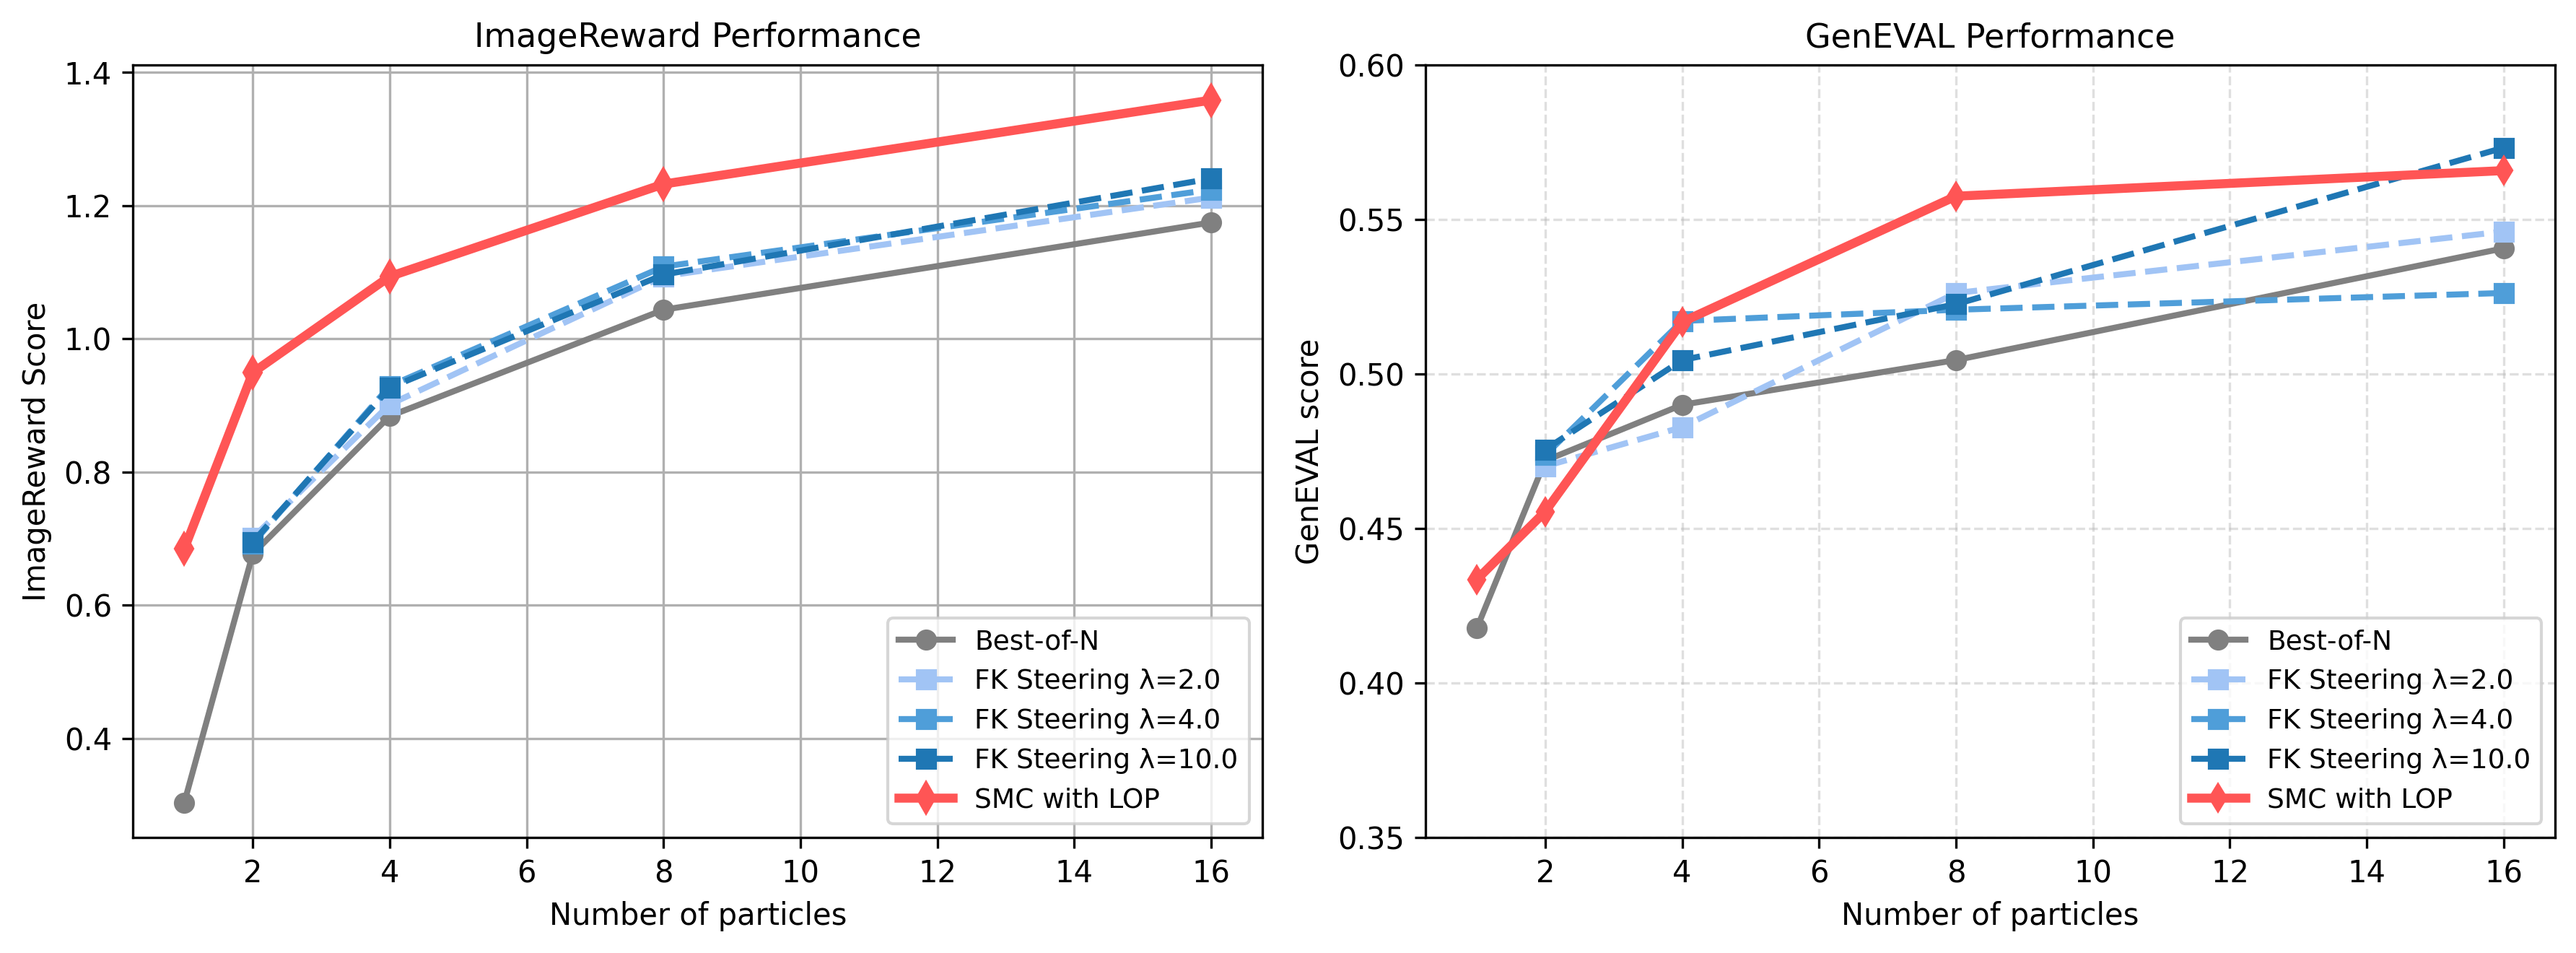

In [24]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURE YOUR ROOT FOLDERS HERE ---
root_folders = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs"
}

outputs_roots = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs"
}

results_roots = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_results_best",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_results_best"
}

# Data accumulators for ImageReward/HumanPreference
data1 = {True: {}, False: {}}  # data1[smc_flag][lambda][nparts] = list of metrics
data2 = {}

# Data accumulators for GenEVAL
geneval_data1 = {True: {}, False: {}}  # geneval_data1[smc_flag][lambda][nparts] = list of genEval_scores
geneval_data2 = {}

def _to_bool(v):
    """Robust conversion for boolean-like values in args.json"""
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)):
        return bool(v)
    if isinstance(v, str):
        return v.strip().lower() in ("1", "true", "yes", "y", "t")
    return False

def collect_first_experiment_metrics(root):
    """Collect ImageReward and HumanPreference metrics"""
    for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse arguments
        nparts = int(args.get("num_particles"))
        smc = _to_bool(args.get("use_smc", False))
        lmbda = args.get("lmbda", None)
        lmbda = float(lmbda) if lmbda is not None else None

        data1[smc].setdefault(lmbda, {}).setdefault(nparts, [])

        # iterate samples in run folder
        for sample in sorted(os.listdir(run)):
            rj = os.path.join(run, sample, "results.json")
            if not os.path.isfile(rj):
                continue

            with open(rj, "r") as fh:
                R = json.load(fh)

            # expected keys
            ir = R["ImageReward"]["max"]
            hp = R["HumanPreference"]["max"]

            data1[smc][lmbda][nparts].append((ir, hp))

def collect_second_experiment_metrics(root):
    """Collect ImageReward and HumanPreference metrics for second experiment"""
    for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse num_particles
        nparts = int(args.get("num_particles"))

        # parse kl_weight (allow missing -> None)
        klw = args.get("kl_weight", None)
        klw = float(klw) if klw is not None else None

        data2.setdefault(klw, {}).setdefault(nparts, [])

        for sample in sorted(os.listdir(run)):
            rj = os.path.join(run, sample, "results.json")
            if not os.path.isfile(rj):
                continue

            with open(rj, "r") as fh:
                R = json.load(fh)

            ir = R["ImageReward"]["max"]
            hp = R["HumanPreference"]["max"]

            data2[klw][nparts].append((ir, hp))

def collect_first_experiment_geneval(outputs_root, results_root):
    """Collect GenEVAL scores for first experiment"""
    for run_dir in sorted(os.listdir(outputs_root)):
        run_out = os.path.join(outputs_root, run_dir)
        if not os.path.isdir(run_out):
            continue
        argsf = os.path.join(run_out, "args.json")
        if not os.path.isfile(argsf):
            continue
        try:
            with open(argsf, "r") as f:
                args = json.load(f)
        except Exception as e:
            print(f"failed to read args.json for {run_dir}: {e}")
            continue

        nparts = args.get("num_particles")
        smc = bool(args.get("use_smc"))
        lam_raw = args.get("lmbda", None)
        try:
            lam = float(lam_raw) if lam_raw is not None else None
        except Exception:
            lam = None

        # prepare data structure
        geneval_data1[smc].setdefault(lam, {}).setdefault(nparts, [])

        # Deterministic mapping to summary.json
        summary_path = os.path.join(results_root, run_dir, "summary.json")
        if not os.path.isfile(summary_path):
            continue

        try:
            with open(summary_path, "r") as rf:
                R = json.load(rf)
            gen_eval_score = R.get("correct_images", R.get("overall_score"))
            if gen_eval_score is None:
                continue
            gen_eval_score = float(gen_eval_score)
            geneval_data1[smc][lam][nparts].append(gen_eval_score)
        except Exception as e:
            print(f"failed to read/parse {summary_path}: {e}")

def collect_second_experiment_geneval(outputs_root, results_root):
    """Collect GenEVAL scores for second experiment"""
    for run_dir in sorted(os.listdir(outputs_root)):
        run_out = os.path.join(outputs_root, run_dir)
        if not os.path.isdir(run_out):
            continue
        argsf = os.path.join(run_out, "args.json")
        if not os.path.isfile(argsf):
            continue
        try:
            with open(argsf, "r") as f:
                args = json.load(f)
        except Exception as e:
            print(f"failed to read args.json for {run_dir}: {e}")
            continue

        nparts = args.get("num_particles")
        kl_raw = args.get("kl_weight", None)
        try:
            kl = float(kl_raw) if kl_raw is not None else None
        except Exception:
            kl = None

        geneval_data2.setdefault(kl, {}).setdefault(nparts, [])

        summary_path = os.path.join(results_root, run_dir, "summary.json")
        if not os.path.isfile(summary_path):
            continue

        try:
            with open(summary_path, "r") as rf:
                R = json.load(rf)
            gen_eval_score = R.get("overall_score", R.get("correct_images"))
            if gen_eval_score is None:
                continue
            gen_eval_score = float(gen_eval_score)
            geneval_data2[kl][nparts].append(gen_eval_score)
        except Exception as e:
            print(f"failed to read/parse {summary_path}: {e}")

def prepare_plot_data(particles_dict, idx):
    """
    particles_dict: {nparts: [(ir, hp), ...]}
    idx: 0 for IR, 1 for HP
    returns xs, ys where ys = mean of element idx
    """
    xs, ys = [], []
    for n in sorted(particles_dict.keys()):
        vals = [v[idx] for v in particles_dict[n] if v is not None]
        if len(vals) == 0:
            continue
        xs.append(n)
        ys.append(float(np.mean(vals)))
    return xs, ys

def prepare_plot_data_particles_dict(particles_dict):
    """
    particles_dict: {nparts: [score, ...]}
    returns xs, ys where ys = mean of scores for each nparts (sorted by nparts)
    """
    xs, ys = [], []
    for n in sorted(particles_dict):
        vals = particles_dict[n]
        if not vals:
            continue
        xs.append(n)
        ys.append(np.mean(vals))
    return xs, ys

def plot_combined_metrics():
    """Create combined figure with ImageReward/HumanPreference and GenEVAL subplots"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # Colors for consistent styling
    fk_colors = ['#a1c4f5', '#4f9ed9', '#1f77b4']
    lop_colors = ['#ff0000', '#ff5555']
    
    # Left subplot: ImageReward
    idx = 0  # ImageReward index
    
    # Best-of-N (SMC=False) for ImageReward
    bosn_lams = [k for k in data1[False].keys() if k is not None] or list(data1[False].keys())
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data(data1[False][lam0], idx)
        if xs:
            ax1.plot(xs, ys, 'o-', lw=2, label="Best-of-N", color='gray')

    # SMC with varying λ for ImageReward
    for i, lam in enumerate(sorted([k for k in data1[True].keys() if k is not None])):
        xs, ys = prepare_plot_data(data1[True][lam], idx)
        if not xs:
            continue
        color = fk_colors[i % len(fk_colors)]
        ax1.plot(xs, ys, 's--', lw=2, color=color, label=f"FK Steering λ={lam}")

    # SMC with LOP for ImageReward
    kl_weights = sorted(data2.keys(), key=lambda x: (x is None, x))
    for i, klw in enumerate(kl_weights):
        if klw == 0.01:
            continue
        xs, ys = prepare_plot_data(data2[klw], idx)
        if not xs:
            continue
        color = lop_colors[i % len(lop_colors)]
        label = "SMC with LOP"
        ax1.plot(xs, ys, marker='d', linestyle='-', linewidth=3, markersize=7,
                markerfacecolor=color, color=color, label=label)

    ax1.set_xlabel("Number of particles")
    ax1.set_ylabel("ImageReward Score")
    ax1.legend()
    ax1.grid(True)
    ax1.set_title("ImageReward Performance")
    
    # Right subplot: GenEVAL
    # Best-of-N for GenEVAL
    bosn_lams = [k for k in geneval_data1[False].keys()]
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data_particles_dict(geneval_data1[False][lam0])
        if xs:
            ax2.plot(xs, ys, 'o-', lw=2, label="Best-of-N", color='gray')

    # SMC with varying λ for GenEVAL
    lam_keys = [k for k in geneval_data1[True].keys() if k is not None]
    for i, lam in enumerate(sorted(lam_keys)):
        xs, ys = prepare_plot_data_particles_dict(geneval_data1[True][lam])
        if not xs:
            continue
        c = fk_colors[i % len(fk_colors)]
        ax2.plot(xs, ys, 's--', lw=2, label=f"FK Steering λ={lam}", color=c)

    # SMC with LOP for GenEVAL
    kl_keys = sorted(geneval_data2.keys(), key=lambda x: (x is None, x))
    for i, kl in enumerate(kl_keys):
        if kl == 0.01:
            continue
        particles_dict = geneval_data2[kl]
        xs, ys = prepare_plot_data_particles_dict(particles_dict)
        if not xs:
            continue
        c = lop_colors[i % len(lop_colors)]
        label = "SMC with LOP"
        ax2.plot(xs, ys, 'd-', lw=3, markersize=6, markerfacecolor=c, label=label, color=c)

    ax2.set_xlabel("Number of particles")
    ax2.set_ylabel("GenEVAL score")
    ax2.set_ylim(0.35, 0.60)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.4)
    ax2.set_title("GenEVAL Performance")
    
    plt.tight_layout()
    return fig, (ax1, ax2)

def summary_counts():
    """Print summary of collected data"""
    print("Summary of collected runs:")
    print("\n--- ImageReward/HumanPreference Data ---")
    for smc_flag in (False, True):
        for lam, d in data1[smc_flag].items():
            total_runs = sum(len(v) for v in d.values())
            print(f"data1 smc={smc_flag} lam={lam}: {total_runs} runs across {len(d)} particle settings")
    for kl, d in data2.items():
        total_runs = sum(len(v) for v in d.values())
        print(f"data2 kl_weight={kl}: {total_runs} runs across {len(d)} particle settings")
    
    print("\n--- GenEVAL Data ---")
    for smc_flag in (False, True):
        for lam, d in geneval_data1[smc_flag].items():
            total_runs = sum(len(v) for v in d.values())
            print(f"geneval_data1 smc={smc_flag} lam={lam}: {total_runs} runs across {len(d)} particle settings")
    for kl, d in geneval_data2.items():
        total_runs = sum(len(v) for v in d.values())
        print(f"geneval_data2 kl_weight={kl}: {total_runs} runs across {len(d)} particle settings")

if __name__ == "__main__":
    # Collect all data
    print("Collecting ImageReward/HumanPreference data...")
    collect_first_experiment_metrics(root_folders["SMC-steering"])
    collect_second_experiment_metrics(root_folders["SMC-Meissonic-LOP"])
    
    print("Collecting GenEVAL data...")
    collect_first_experiment_geneval(outputs_roots["SMC-steering"], results_roots["SMC-steering"])
    collect_second_experiment_geneval(outputs_roots["SMC-Meissonic-LOP"], results_roots["SMC-Meissonic-LOP"])
    
    # Print summary
    summary_counts()
    
    # Create combined plot
    fig, (ax1, ax2) = plot_combined_metrics()
    
    # Save and show
    outname = "combined_metrics_comparison.pdf"
    plt.savefig(outname, format="pdf", bbox_inches='tight')
    print(f"\nSaved combined plot to {outname}")
    plt.show()

In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200

# --- CONFIGURE YOUR ROOT FOLDERS HERE ---
root_folders = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs"
}

outputs_roots = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs"
}

results_roots = {
    "SMC-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_results_best",
    "SMC-Meissonic-LOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_results_best"
}

# Data accumulators for ImageReward/HumanPreference
data1 = {True: {}, False: {}}  # data1[smc_flag][lambda][nparts] = list of metrics
data2 = {}

# Data accumulators for GenEVAL
geneval_data1 = {True: {}, False: {}}  # geneval_data1[smc_flag][lambda][nparts] = list of genEval_scores
geneval_data2 = {}

Summary of collected runs:

--- ImageReward/HumanPreference Data ---
data1 smc=False lam=2.0: 2765 runs across 5 particle settings
data1 smc=True lam=2.0: 2212 runs across 4 particle settings
data1 smc=True lam=4.0: 2212 runs across 4 particle settings
data1 smc=True lam=10.0: 2212 runs across 4 particle settings
data1 smc=True lam=50.0: 2212 runs across 4 particle settings
data2 kl_weight=0.01: 2765 runs across 5 particle settings
data2 kl_weight=0.02: 2765 runs across 5 particle settings

--- GenEVAL Data ---
geneval_data1 smc=False lam=2.0: 5 runs across 5 particle settings
geneval_data1 smc=True lam=2.0: 4 runs across 4 particle settings
geneval_data1 smc=True lam=4.0: 4 runs across 4 particle settings
geneval_data1 smc=True lam=10.0: 4 runs across 4 particle settings
geneval_data1 smc=True lam=50.0: 4 runs across 4 particle settings
geneval_data2 kl_weight=0.01: 5 runs across 5 particle settings
geneval_data2 kl_weight=0.02: 5 runs across 5 particle settings

Saved combined plot t

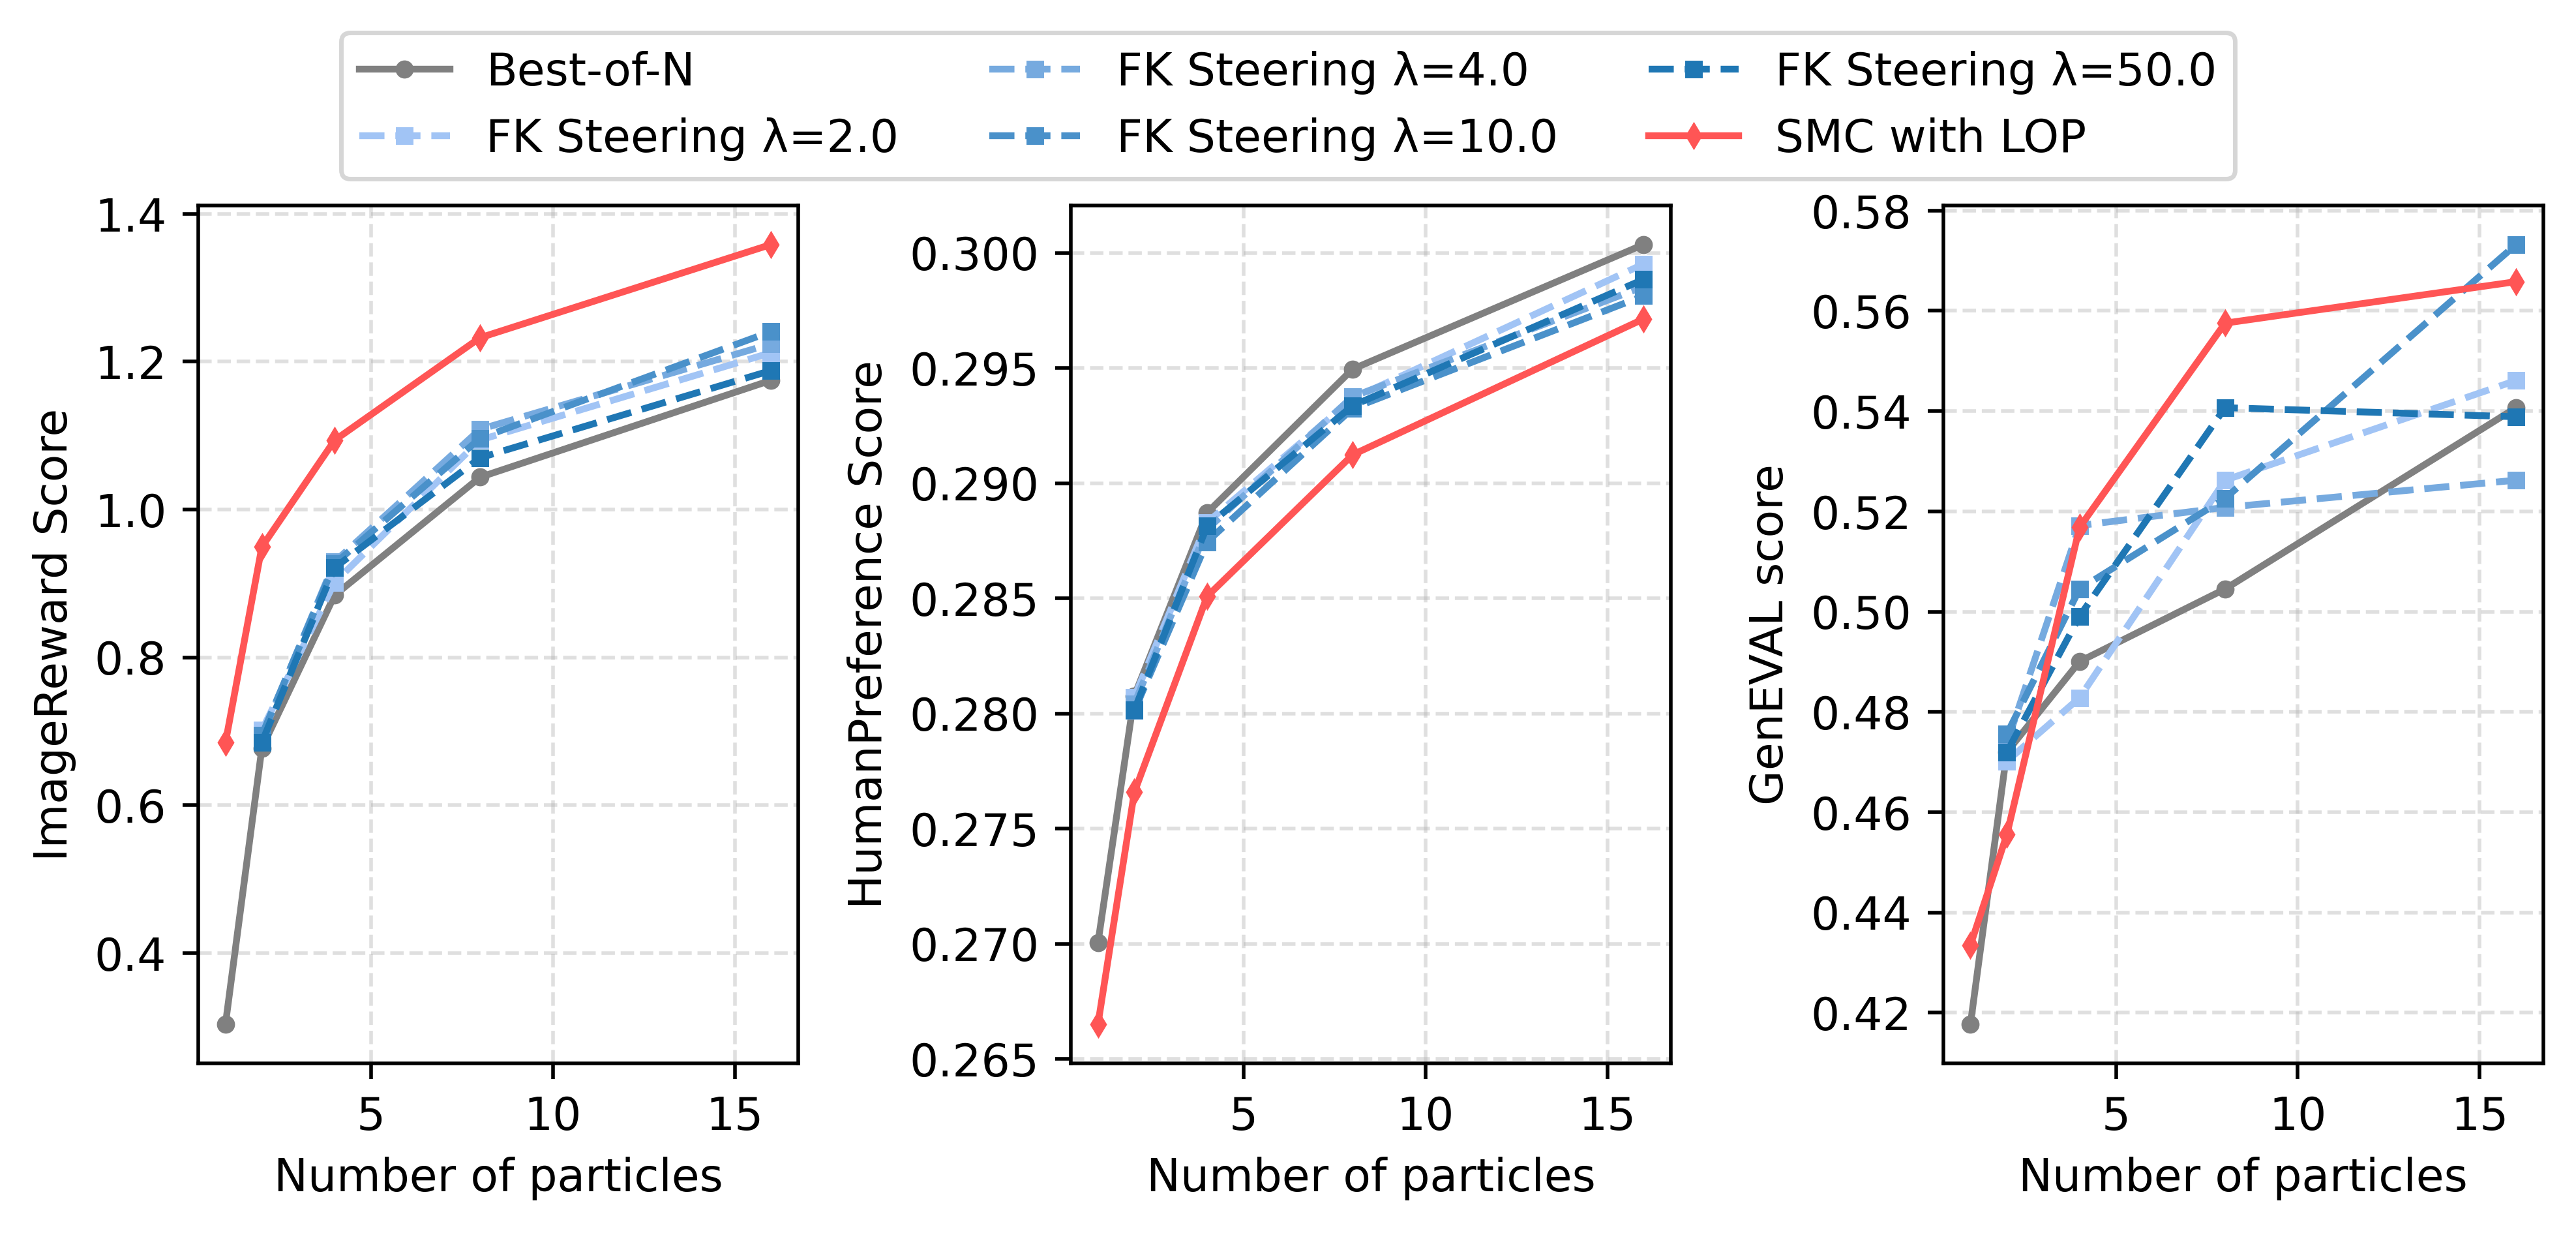

In [ ]:
# Plot for paper

plt.rcParams['figure.dpi'] = 500
lw = 1.5 #line width
marker_size = 3


def _to_bool(v):
    """Robust conversion for boolean-like values in args.json"""
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)):
        return bool(v)
    if isinstance(v, str):
        return v.strip().lower() in ("1", "true", "yes", "y", "t")
    return False

def collect_first_experiment_metrics(root):
    """Collect ImageReward and HumanPreference metrics"""
    for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse arguments
        nparts = int(args.get("num_particles"))
        smc = _to_bool(args.get("use_smc", False))
        lmbda = args.get("lmbda", None)
        lmbda = float(lmbda) if lmbda is not None else None

        data1[smc].setdefault(lmbda, {}).setdefault(nparts, [])

        # iterate samples in run folder
        for sample in sorted(os.listdir(run)):
            rj = os.path.join(run, sample, "results.json")
            if not os.path.isfile(rj):
                continue

            with open(rj, "r") as fh:
                R = json.load(fh)

            # expected keys
            ir = R["ImageReward"]["max"]
            hp = R["HumanPreference"]["max"]

            data1[smc][lmbda][nparts].append((ir, hp))

def collect_second_experiment_metrics(root):
    """Collect ImageReward and HumanPreference metrics for second experiment"""
    for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse num_particles
        nparts = int(args.get("num_particles"))

        # parse kl_weight (allow missing -> None)
        klw = args.get("kl_weight", None)
        klw = float(klw) if klw is not None else None

        data2.setdefault(klw, {}).setdefault(nparts, [])

        for sample in sorted(os.listdir(run)):
            rj = os.path.join(run, sample, "results.json")
            if not os.path.isfile(rj):
                continue

            with open(rj, "r") as fh:
                R = json.load(fh)

            ir = R["ImageReward"]["max"]
            hp = R["HumanPreference"]["max"]

            data2[klw][nparts].append((ir, hp))

def collect_first_experiment_geneval(outputs_root, results_root):
    """Collect GenEVAL scores for first experiment"""
    for run_dir in sorted(os.listdir(outputs_root)):
        run_out = os.path.join(outputs_root, run_dir)
        if not os.path.isdir(run_out):
            continue
        argsf = os.path.join(run_out, "args.json")
        if not os.path.isfile(argsf):
            continue
        try:
            with open(argsf, "r") as f:
                args = json.load(f)
        except Exception as e:
            print(f"failed to read args.json for {run_dir}: {e}")
            continue

        nparts = args.get("num_particles")
        smc = bool(args.get("use_smc"))
        lam_raw = args.get("lmbda", None)
        try:
            lam = float(lam_raw) if lam_raw is not None else None
        except Exception:
            lam = None

        # prepare data structure
        geneval_data1[smc].setdefault(lam, {}).setdefault(nparts, [])

        # Deterministic mapping to summary.json
        summary_path = os.path.join(results_root, run_dir, "summary.json")
        if not os.path.isfile(summary_path):
            continue

        try:
            with open(summary_path, "r") as rf:
                R = json.load(rf)
            gen_eval_score = R.get("correct_images", R.get("overall_score"))
            if gen_eval_score is None:
                continue
            gen_eval_score = float(gen_eval_score)
            geneval_data1[smc][lam][nparts].append(gen_eval_score)
        except Exception as e:
            print(f"failed to read/parse {summary_path}: {e}")

def collect_second_experiment_geneval(outputs_root, results_root):
    """Collect GenEVAL scores for second experiment"""
    for run_dir in sorted(os.listdir(outputs_root)):
        run_out = os.path.join(outputs_root, run_dir)
        if not os.path.isdir(run_out):
            continue
        argsf = os.path.join(run_out, "args.json")
        if not os.path.isfile(argsf):
            continue
        try:
            with open(argsf, "r") as f:
                args = json.load(f)
        except Exception as e:
            print(f"failed to read args.json for {run_dir}: {e}")
            continue

        nparts = args.get("num_particles")
        kl_raw = args.get("kl_weight", None)
        try:
            kl = float(kl_raw) if kl_raw is not None else None
        except Exception:
            kl = None

        geneval_data2.setdefault(kl, {}).setdefault(nparts, [])

        summary_path = os.path.join(results_root, run_dir, "summary.json")
        if not os.path.isfile(summary_path):
            continue

        try:
            with open(summary_path, "r") as rf:
                R = json.load(rf)
            gen_eval_score = R.get("overall_score", R.get("correct_images"))
            if gen_eval_score is None:
                continue
            gen_eval_score = float(gen_eval_score)
            geneval_data2[kl][nparts].append(gen_eval_score)
        except Exception as e:
            print(f"failed to read/parse {summary_path}: {e}")

def prepare_plot_data(particles_dict, idx):
    """
    particles_dict: {nparts: [(ir, hp), ...]}
    idx: 0 for IR, 1 for HP
    returns xs, ys where ys = mean of element idx
    """
    xs, ys = [], []
    for n in sorted(particles_dict.keys()):
        vals = [v[idx] for v in particles_dict[n] if v is not None]
        if len(vals) == 0:
            continue
        xs.append(n)
        ys.append(float(np.mean(vals)))
    return xs, ys

def prepare_plot_data_particles_dict(particles_dict):
    """
    particles_dict: {nparts: [score, ...]}
    returns xs, ys where ys = mean of scores for each nparts (sorted by nparts)
    """
    xs, ys = [], []
    for n in sorted(particles_dict):
        vals = particles_dict[n]
        if not vals:
            continue
        xs.append(n)
        ys.append(np.mean(vals))
    return xs, ys

def plot_combined_metrics():
    """Create combined figure with ImageReward, HumanPreference, and GenEVAL subplots"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 4))
    
    # Colors for consistent styling
    # fk_colors = ['#a1c4f5', '#4f9ed9', '#1f77b4']
    fk_colors = ['#a1c4f5', '#76aadf', '#4a91ca', '#1f77b4']
    lop_colors = ['#ff0000', '#ff5555']
    
    # Collect all legend handles and labels for unified legend
    legend_handles = []
    legend_labels = []
    
    # Left subplot: ImageReward
    idx = 0  # ImageReward index
    
    # Best-of-N (SMC=False) for ImageReward
    bosn_lams = [k for k in data1[False].keys() if k is not None] or list(data1[False].keys())
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data(data1[False][lam0], idx)
        if xs:
            line = ax1.plot(xs, ys, 'o-', lw=lw, color='gray', markersize=marker_size)[0]
            if "Best-of-N" not in legend_labels:
                legend_handles.append(line)
                legend_labels.append("Best-of-N")

    # SMC with varying λ for ImageReward
    for i, lam in enumerate(sorted([k for k in data1[True].keys() if k is not None])):
        # if lam == 50:
        #     continue
        xs, ys = prepare_plot_data(data1[True][lam], idx)
        if not xs:
            continue
        color = fk_colors[i % len(fk_colors)]
        line = ax1.plot(xs, ys, 's--', lw=lw, color=color, markersize=marker_size)[0]
        label = f"FK Steering λ={lam}"
        if label not in legend_labels:
            legend_handles.append(line)
            legend_labels.append(label)

    # SMC with LOP for ImageReward
    kl_weights = sorted(data2.keys(), key=lambda x: (x is None, x))
    for i, klw in enumerate(kl_weights):
        if klw == 0.01:
            continue
        xs, ys = prepare_plot_data(data2[klw], idx)
        if not xs:
            continue
        color = lop_colors[i % len(lop_colors)]
        line = ax1.plot(xs, ys, marker='d', linestyle='-', linewidth=lw, markersize=marker_size,
                markerfacecolor=color, color=color)[0]
        label = "SMC with LOP"
        if label not in legend_labels:
            legend_handles.append(line)
            legend_labels.append(label)

    ax1.set_xlabel("Number of particles")
    ax1.set_ylabel("ImageReward Score")
    ax1.grid(True, linestyle='--', alpha=0.4)
    # ax1.set_title("ImageReward Performance")
    
    # Middle subplot: HumanPreference
    idx = 1  # HumanPreference index
    
    # Best-of-N (SMC=False) for HumanPreference
    bosn_lams = [k for k in data1[False].keys() if k is not None] or list(data1[False].keys())
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data(data1[False][lam0], idx)
        if xs:
            ax2.plot(xs, ys, 'o-', lw=lw, color='gray', markersize=marker_size)

    # SMC with varying λ for HumanPreference
    for i, lam in enumerate(sorted([k for k in data1[True].keys() if k is not None])):
        # if lam == 50:
        #     continue
        xs, ys = prepare_plot_data(data1[True][lam], idx)
        if not xs:
            continue
        color = fk_colors[i % len(fk_colors)]
        ax2.plot(xs, ys, 's--', lw=lw, color=color, markersize=marker_size)

    # SMC with LOP for HumanPreference
    kl_weights = sorted(data2.keys(), key=lambda x: (x is None, x))
    for i, klw in enumerate(kl_weights):
        if klw == 0.01:
            continue
        xs, ys = prepare_plot_data(data2[klw], idx)
        if not xs:
            continue
        color = lop_colors[i % len(lop_colors)]
        ax2.plot(xs, ys, marker='d', linestyle='-', linewidth=lw, markersize=marker_size,
                markerfacecolor=color, color=color)

    ax2.set_xlabel("Number of particles")
    ax2.set_ylabel("HumanPreference Score")
    ax2.grid(True, linestyle='--', alpha=0.4)
    # ax2.set_title("HumanPreference Performance")
    
    # Right subplot: GenEVAL
    # Best-of-N for GenEVAL
    bosn_lams = [k for k in geneval_data1[False].keys()]
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data_particles_dict(geneval_data1[False][lam0])
        if xs:
            ax3.plot(xs, ys, 'o-', lw=lw, color='gray', markersize=marker_size)

    # SMC with varying λ for GenEVAL
    lam_keys = [k for k in geneval_data1[True].keys() if k is not None]
    for i, lam in enumerate(sorted(lam_keys)):
        xs, ys = prepare_plot_data_particles_dict(geneval_data1[True][lam])
        if not xs:
            continue
        c = fk_colors[i % len(fk_colors)]
        ax3.plot(xs, ys, 's--', lw=lw, color=c, markersize=marker_size)

    # SMC with LOP for GenEVAL
    kl_keys = sorted(geneval_data2.keys(), key=lambda x: (x is None, x))
    for i, kl in enumerate(kl_keys):
        if kl == 0.01:
            continue
        particles_dict = geneval_data2[kl]
        xs, ys = prepare_plot_data_particles_dict(particles_dict)
        if not xs:
            continue
        c = lop_colors[i % len(lop_colors)]
        ax3.plot(xs, ys, 'd-', lw=lw, markersize=marker_size, markerfacecolor=c, color=c)

    ax3.set_xlabel("Number of particles")
    ax3.set_ylabel("GenEVAL score")
    # ax3.set_ylim(0.35, 0.60)
    ax3.grid(True, linestyle='--', alpha=0.4)
    # ax3.set_title("GenEVAL Performance")
    
    # for ax in [ax1, ax2, ax3]:
        # ax.set_xscale('log')
        # ax.set_xticks([1, 2, 4, 8, 16])
        # ax.set_xticklabels([1, 2, 4, 8, 16])
    
    # Create single legend at the top of the figure
    fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.80)  # Make room for the legend
    return fig, (ax1, ax2, ax3)

def summary_counts():
    """Print summary of collected data"""
    print("Summary of collected runs:")
    print("\n--- ImageReward/HumanPreference Data ---")
    for smc_flag in (False, True):
        for lam, d in data1[smc_flag].items():
            total_runs = sum(len(v) for v in d.values())
            print(f"data1 smc={smc_flag} lam={lam}: {total_runs} runs across {len(d)} particle settings")
    for kl, d in data2.items():
        total_runs = sum(len(v) for v in d.values())
        print(f"data2 kl_weight={kl}: {total_runs} runs across {len(d)} particle settings")
    
    print("\n--- GenEVAL Data ---")
    for smc_flag in (False, True):
        for lam, d in geneval_data1[smc_flag].items():
            total_runs = sum(len(v) for v in d.values())
            print(f"geneval_data1 smc={smc_flag} lam={lam}: {total_runs} runs across {len(d)} particle settings")
    for kl, d in geneval_data2.items():
        total_runs = sum(len(v) for v in d.values())
        print(f"geneval_data2 kl_weight={kl}: {total_runs} runs across {len(d)} particle settings")

if __name__ == "__main__":
    # Collect all data
    print("Collecting ImageReward/HumanPreference data...")
    # collect_first_experiment_metrics(root_folders["SMC-steering"])
    # collect_second_experiment_metrics(root_folders["SMC-Meissonic-LOP"])
    
    print("Collecting GenEVAL data...")
    # collect_first_experiment_geneval(outputs_roots["SMC-steering"], results_roots["SMC-steering"])
    # collect_second_experiment_geneval(outputs_roots["SMC-Meissonic-LOP"], results_roots["SMC-Meissonic-LOP"])
    
    # Print summary
    summary_counts()
    
    # Create combined plot
    fig, (ax1, ax2, ax3) = plot_combined_metrics()
    
    # Save and show
    outname = "combined_metrics_comparison.pdf"
    plt.savefig(outname, format="pdf", bbox_inches='tight')
    print(f"\nSaved combined plot to {outname}")
    plt.show()

Summary of collected runs:

--- ImageReward/HumanPreference Data ---

--- GenEVAL Data ---

Saved combined plot to t2i_meissonic_comparison_thesis.pdf


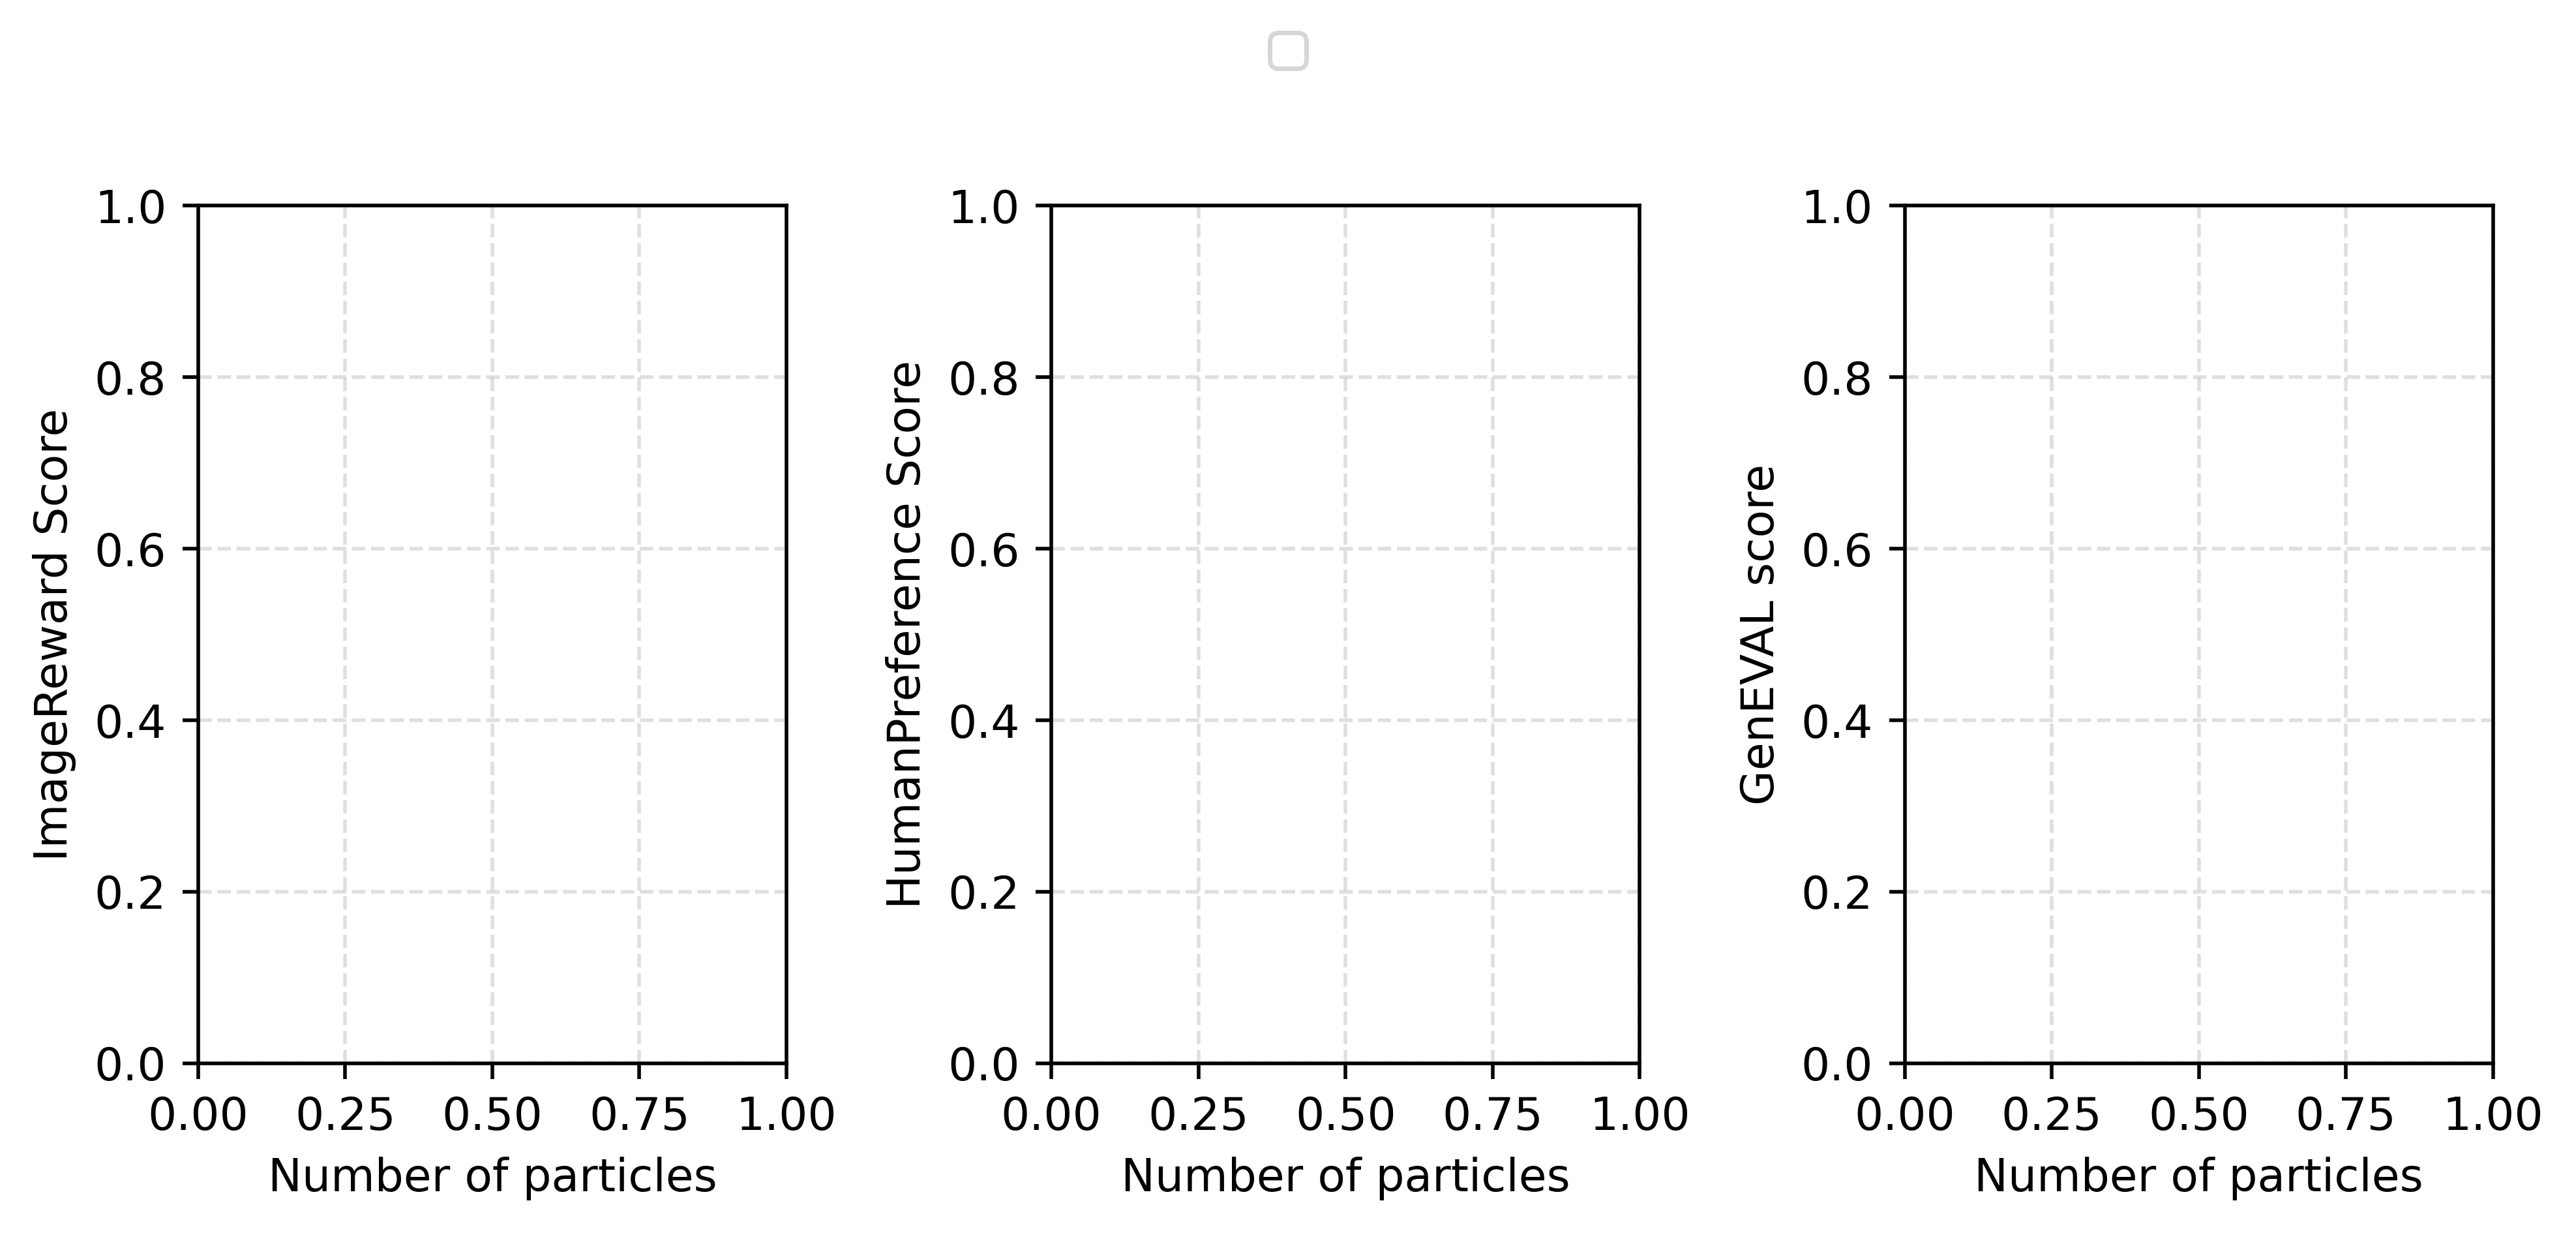

In [5]:
# Plot for thesis

plt.rcParams['figure.dpi'] = 500
lw = 1.5 #line width
marker_size = 3


def _to_bool(v):
    """Robust conversion for boolean-like values in args.json"""
    if isinstance(v, bool):
        return v
    if isinstance(v, (int, float)):
        return bool(v)
    if isinstance(v, str):
        return v.strip().lower() in ("1", "true", "yes", "y", "t")
    return False

def collect_first_experiment_metrics(root):
    """Collect ImageReward and HumanPreference metrics"""
    for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse arguments
        nparts = int(args.get("num_particles"))
        smc = _to_bool(args.get("use_smc", False))
        lmbda = args.get("lmbda", None)
        lmbda = float(lmbda) if lmbda is not None else None

        data1[smc].setdefault(lmbda, {}).setdefault(nparts, [])

        # iterate samples in run folder
        for sample in sorted(os.listdir(run)):
            rj = os.path.join(run, sample, "results.json")
            if not os.path.isfile(rj):
                continue

            with open(rj, "r") as fh:
                R = json.load(fh)

            # expected keys
            ir = R["ImageReward"]["max"]
            hp = R["HumanPreference"]["max"]

            data1[smc][lmbda][nparts].append((ir, hp))

def collect_second_experiment_metrics(root):
    """Collect ImageReward and HumanPreference metrics for second experiment"""
    for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse num_particles
        nparts = int(args.get("num_particles"))

        # parse kl_weight (allow missing -> None)
        klw = args.get("kl_weight", None)
        klw = float(klw) if klw is not None else None

        data2.setdefault(klw, {}).setdefault(nparts, [])

        for sample in sorted(os.listdir(run)):
            rj = os.path.join(run, sample, "results.json")
            if not os.path.isfile(rj):
                continue

            with open(rj, "r") as fh:
                R = json.load(fh)

            ir = R["ImageReward"]["max"]
            hp = R["HumanPreference"]["max"]

            data2[klw][nparts].append((ir, hp))

def collect_first_experiment_geneval(outputs_root, results_root):
    """Collect GenEVAL scores for first experiment"""
    for run_dir in sorted(os.listdir(outputs_root)):
        run_out = os.path.join(outputs_root, run_dir)
        if not os.path.isdir(run_out):
            continue
        argsf = os.path.join(run_out, "args.json")
        if not os.path.isfile(argsf):
            continue
        try:
            with open(argsf, "r") as f:
                args = json.load(f)
        except Exception as e:
            print(f"failed to read args.json for {run_dir}: {e}")
            continue

        nparts = args.get("num_particles")
        smc = bool(args.get("use_smc"))
        lam_raw = args.get("lmbda", None)
        try:
            lam = float(lam_raw) if lam_raw is not None else None
        except Exception:
            lam = None

        # prepare data structure
        geneval_data1[smc].setdefault(lam, {}).setdefault(nparts, [])

        # Deterministic mapping to summary.json
        summary_path = os.path.join(results_root, run_dir, "summary.json")
        if not os.path.isfile(summary_path):
            continue

        try:
            with open(summary_path, "r") as rf:
                R = json.load(rf)
            gen_eval_score = R.get("correct_images", R.get("overall_score"))
            if gen_eval_score is None:
                continue
            gen_eval_score = float(gen_eval_score)
            geneval_data1[smc][lam][nparts].append(gen_eval_score)
        except Exception as e:
            print(f"failed to read/parse {summary_path}: {e}")

def collect_second_experiment_geneval(outputs_root, results_root):
    """Collect GenEVAL scores for second experiment"""
    for run_dir in sorted(os.listdir(outputs_root)):
        run_out = os.path.join(outputs_root, run_dir)
        if not os.path.isdir(run_out):
            continue
        argsf = os.path.join(run_out, "args.json")
        if not os.path.isfile(argsf):
            continue
        try:
            with open(argsf, "r") as f:
                args = json.load(f)
        except Exception as e:
            print(f"failed to read args.json for {run_dir}: {e}")
            continue

        nparts = args.get("num_particles")
        kl_raw = args.get("kl_weight", None)
        try:
            kl = float(kl_raw) if kl_raw is not None else None
        except Exception:
            kl = None

        geneval_data2.setdefault(kl, {}).setdefault(nparts, [])

        summary_path = os.path.join(results_root, run_dir, "summary.json")
        if not os.path.isfile(summary_path):
            continue

        try:
            with open(summary_path, "r") as rf:
                R = json.load(rf)
            gen_eval_score = R.get("overall_score", R.get("correct_images"))
            if gen_eval_score is None:
                continue
            gen_eval_score = float(gen_eval_score)
            geneval_data2[kl][nparts].append(gen_eval_score)
        except Exception as e:
            print(f"failed to read/parse {summary_path}: {e}")

def prepare_plot_data(particles_dict, idx):
    """
    particles_dict: {nparts: [(ir, hp), ...]}
    idx: 0 for IR, 1 for HP
    returns xs, ys where ys = mean of element idx
    """
    xs, ys = [], []
    for n in sorted(particles_dict.keys()):
        vals = [v[idx] for v in particles_dict[n] if v is not None]
        if len(vals) == 0:
            continue
        xs.append(n)
        ys.append(float(np.mean(vals)))
    return xs, ys

def prepare_plot_data_particles_dict(particles_dict):
    """
    particles_dict: {nparts: [score, ...]}
    returns xs, ys where ys = mean of scores for each nparts (sorted by nparts)
    """
    xs, ys = [], []
    for n in sorted(particles_dict):
        vals = particles_dict[n]
        if not vals:
            continue
        xs.append(n)
        ys.append(np.mean(vals))
    return xs, ys

def plot_combined_metrics():
    """Create combined figure with ImageReward, HumanPreference, and GenEVAL subplots"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 4))
    
    # Colors for consistent styling
    # fk_colors = ['#a1c4f5', '#4f9ed9', '#1f77b4']
    fk_colors = ['#a1c4f5', '#76aadf', '#4a91ca', '#1f77b4']
    lop_colors = ['#ff0000', '#ff5555']
    
    # Collect all legend handles and labels for unified legend
    legend_handles = []
    legend_labels = []
    
    # Left subplot: ImageReward
    idx = 0  # ImageReward index
    
    # Best-of-N (SMC=False) for ImageReward
    bosn_lams = [k for k in data1[False].keys() if k is not None] or list(data1[False].keys())
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data(data1[False][lam0], idx)
        if xs:
            line = ax1.plot(xs, ys, 'o-', lw=lw, color='gray', markersize=marker_size)[0]
            if "Best-of-N" not in legend_labels:
                legend_handles.append(line)
                legend_labels.append("Best-of-N")

    # SMC with varying λ for ImageReward
    for i, lam in enumerate(sorted([k for k in data1[True].keys() if k is not None])):
        # if lam == 50:
        #     continue
        xs, ys = prepare_plot_data(data1[True][lam], idx)
        if not xs:
            continue
        color = fk_colors[i % len(fk_colors)]
        line = ax1.plot(xs, ys, 's--', lw=lw, color=color, markersize=marker_size)[0]
        label = f"FK Steering λ={lam}"
        if label not in legend_labels:
            legend_handles.append(line)
            legend_labels.append(label)

    # SMC with LOP for ImageReward
    kl_weights = sorted(data2.keys(), key=lambda x: (x is None, x))
    for i, klw in enumerate(kl_weights):
        if klw == 0.01:
            continue
        xs, ys = prepare_plot_data(data2[klw], idx)
        if not xs:
            continue
        color = lop_colors[i % len(lop_colors)]
        line = ax1.plot(xs, ys, marker='d', linestyle='-', linewidth=lw, markersize=marker_size,
                markerfacecolor=color, color=color)[0]
        label = "SMC-FALOP"
        if label not in legend_labels:
            legend_handles.append(line)
            legend_labels.append(label)

    ax1.set_xlabel("Number of particles")
    ax1.set_ylabel("ImageReward Score")
    ax1.grid(True, linestyle='--', alpha=0.4)
    # ax1.set_title("ImageReward Performance")
    
    # Middle subplot: HumanPreference
    idx = 1  # HumanPreference index
    
    # Best-of-N (SMC=False) for HumanPreference
    bosn_lams = [k for k in data1[False].keys() if k is not None] or list(data1[False].keys())
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data(data1[False][lam0], idx)
        if xs:
            ax2.plot(xs, ys, 'o-', lw=lw, color='gray', markersize=marker_size)

    # SMC with varying λ for HumanPreference
    for i, lam in enumerate(sorted([k for k in data1[True].keys() if k is not None])):
        # if lam == 50:
        #     continue
        xs, ys = prepare_plot_data(data1[True][lam], idx)
        if not xs:
            continue
        color = fk_colors[i % len(fk_colors)]
        ax2.plot(xs, ys, 's--', lw=lw, color=color, markersize=marker_size)

    # SMC with LOP for HumanPreference
    kl_weights = sorted(data2.keys(), key=lambda x: (x is None, x))
    for i, klw in enumerate(kl_weights):
        if klw == 0.01:
            continue
        xs, ys = prepare_plot_data(data2[klw], idx)
        if not xs:
            continue
        color = lop_colors[i % len(lop_colors)]
        ax2.plot(xs, ys, marker='d', linestyle='-', linewidth=lw, markersize=marker_size,
                markerfacecolor=color, color=color)

    ax2.set_xlabel("Number of particles")
    ax2.set_ylabel("HumanPreference Score")
    ax2.grid(True, linestyle='--', alpha=0.4)
    # ax2.set_title("HumanPreference Performance")
    
    # Right subplot: GenEVAL
    # Best-of-N for GenEVAL
    bosn_lams = [k for k in geneval_data1[False].keys()]
    if bosn_lams:
        lam0 = bosn_lams[0]
        xs, ys = prepare_plot_data_particles_dict(geneval_data1[False][lam0])
        if xs:
            ax3.plot(xs, ys, 'o-', lw=lw, color='gray', markersize=marker_size)

    # SMC with varying λ for GenEVAL
    lam_keys = [k for k in geneval_data1[True].keys() if k is not None]
    for i, lam in enumerate(sorted(lam_keys)):
        xs, ys = prepare_plot_data_particles_dict(geneval_data1[True][lam])
        if not xs:
            continue
        c = fk_colors[i % len(fk_colors)]
        ax3.plot(xs, ys, 's--', lw=lw, color=c, markersize=marker_size)

    # SMC with LOP for GenEVAL
    kl_keys = sorted(geneval_data2.keys(), key=lambda x: (x is None, x))
    for i, kl in enumerate(kl_keys):
        if kl == 0.01:
            continue
        particles_dict = geneval_data2[kl]
        xs, ys = prepare_plot_data_particles_dict(particles_dict)
        if not xs:
            continue
        c = lop_colors[i % len(lop_colors)]
        ax3.plot(xs, ys, 'd-', lw=lw, markersize=marker_size, markerfacecolor=c, color=c)

    ax3.set_xlabel("Number of particles")
    ax3.set_ylabel("GenEVAL score")
    # ax3.set_ylim(0.35, 0.60)
    ax3.grid(True, linestyle='--', alpha=0.4)
    # ax3.set_title("GenEVAL Performance")
    
    # for ax in [ax1, ax2, ax3]:
        # ax.set_xscale('log')
        # ax.set_xticks([1, 2, 4, 8, 16])
        # ax.set_xticklabels([1, 2, 4, 8, 16])
    
    # Create single legend at the top of the figure
    fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), ncol=3)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.80)  # Make room for the legend
    return fig, (ax1, ax2, ax3)

def summary_counts():
    """Print summary of collected data"""
    print("Summary of collected runs:")
    print("\n--- ImageReward/HumanPreference Data ---")
    for smc_flag in (False, True):
        for lam, d in data1[smc_flag].items():
            total_runs = sum(len(v) for v in d.values())
            print(f"data1 smc={smc_flag} lam={lam}: {total_runs} runs across {len(d)} particle settings")
    for kl, d in data2.items():
        total_runs = sum(len(v) for v in d.values())
        print(f"data2 kl_weight={kl}: {total_runs} runs across {len(d)} particle settings")
    
    print("\n--- GenEVAL Data ---")
    for smc_flag in (False, True):
        for lam, d in geneval_data1[smc_flag].items():
            total_runs = sum(len(v) for v in d.values())
            print(f"geneval_data1 smc={smc_flag} lam={lam}: {total_runs} runs across {len(d)} particle settings")
    for kl, d in geneval_data2.items():
        total_runs = sum(len(v) for v in d.values())
        print(f"geneval_data2 kl_weight={kl}: {total_runs} runs across {len(d)} particle settings")

if __name__ == "__main__":
    # Collect all data
    print("Collecting ImageReward/HumanPreference data...")
    # collect_first_experiment_metrics(root_folders["SMC-steering"])
    # collect_second_experiment_metrics(root_folders["SMC-Meissonic-LOP"])
    
    print("Collecting GenEVAL data...")
    # collect_first_experiment_geneval(outputs_roots["SMC-steering"], results_roots["SMC-steering"])
    # collect_second_experiment_geneval(outputs_roots["SMC-Meissonic-LOP"], results_roots["SMC-Meissonic-LOP"])
    
    # Print summary
    summary_counts()
    
    # Create combined plot
    fig, (ax1, ax2, ax3) = plot_combined_metrics()
    
    # Save and show
    outname = "t2i_meissonic_comparison_thesis.pdf"
    plt.savefig(outname, format="pdf", bbox_inches='tight')
    print(f"\nSaved combined plot to {outname}")
    plt.show()

In [ ]:
import os
import datetime

path = "geneval_metadata_outputs/20250712-045540/00000"
path2 = "geneval_metadata_outputs/20250712-045540/00001"

# getmtime returns seconds since the epoch
mtime = os.path.getmtime(path)
print(mtime)
mtime2 = os.path.getmtime(path2)
print(mtime2)

# Convert to a readable format
mtime_readable = datetime.datetime.fromtimestamp(mtime)
mtime_readable_2 = datetime.datetime.fromtimestamp(mtime2)

print("Modify time:", mtime_readable)
print("Modify time2:", mtime_readable_2)
print(f"time diff: {mtime2-mtime}s")

1752292592.050853
1752292625.977305
Modify time: 2025-07-12 04:56:32.050853
Modify time2: 2025-07-12 04:57:05.977305
time diff: 33.92645192146301s


In [69]:
import os
import json

outputs_roots = {
    "FK-steering": "/vol/bitbucket/cp524/dev/papers_with_code/Fk-Diffusion-Steering/text_to_image/geneval_metadata_outputs",
    "SMC-FALOP": "/vol/bitbucket/cp524/dev/SMC_Meissonic_2/geneval_metadata_outputs"
}


best_of_n_data = {}
fk_steering_data = {}
falop_data_phi_1 = {}
falop_data_phi_4 = {}

falop_phi_1_batch_sizes = {}
falop_phi_4_batch_sizes = {}

root = outputs_roots["FK-steering"]
for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        mtimes = []
        for out_dir in sorted(os.listdir(run)):
            mtime =  os.path.getmtime(os.path.join(run, out_dir))
            mtimes.append(mtime)

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse arguments
        nparts = int(args.get("num_particles"))
        smc = args.get("use_smc", False)
        lmbda = args.get("lmbda", None)
        lmbda = float(lmbda) if lmbda is not None else None

        if not smc:
            assert best_of_n_data.get(nparts) is None
            best_of_n_data[nparts] = mtimes
        elif lmbda == 10.0:
            # Changing lmbda won't affect runtimes
            assert fk_steering_data.get(nparts) is None
            fk_steering_data[nparts] = mtimes


root = outputs_roots["SMC-FALOP"]
for run_dir in sorted(os.listdir(root)):
        run = os.path.join(root, run_dir)
        argsf = os.path.join(run, "args.json")
        if not os.path.isfile(argsf):
            continue

        mtimes = []
        for out_dir in sorted(os.listdir(run)):
            mtime =  os.path.getmtime(os.path.join(run, out_dir))
            mtimes.append(mtime)

        with open(argsf, "r") as f:
            args = json.load(f)

        # parse arguments
        nparts = int(args.get("num_particles"))
        phi = args.get("phi", None)
        batch_size = args.get("batch_p")

        if phi == 1:
            assert falop_data_phi_1.get(nparts) is None
            falop_data_phi_1[nparts] = mtimes
            falop_phi_1_batch_sizes[nparts] = batch_size
        else:
            assert falop_data_phi_4.get(nparts) is None
            falop_data_phi_4[nparts] = mtimes
            falop_phi_4_batch_sizes[nparts] = batch_size

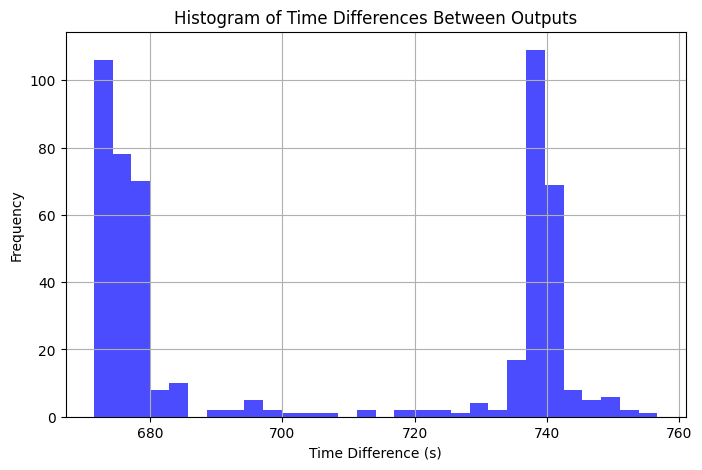

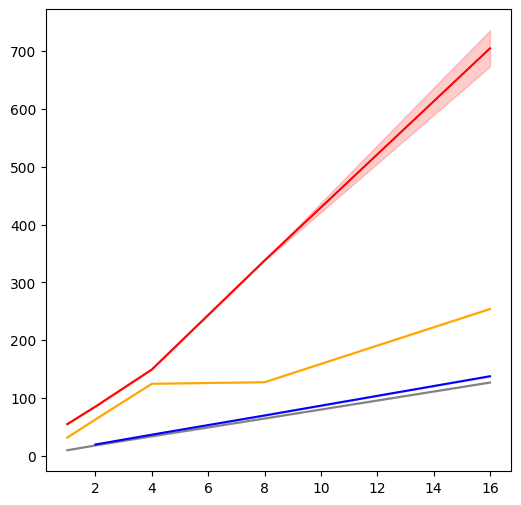

In [76]:
import matplotlib.pyplot as plt
import numpy as np

def get_time_diffs(mtimes):
    mtimes = np.array(mtimes)
    time_diffs = mtimes[1:] - mtimes[:-1]
    return time_diffs

def clean_time_diffs(time_diffs):
    # Remove outliers
    median = np.median(time_diffs)
    # print(median)
    diff_from_median = np.abs(time_diffs - median)
    mad = np.median(diff_from_median)  # Median Absolute Deviation
    threshold = 3 * mad
    cleaned_diffs = time_diffs[diff_from_median < threshold]
    return cleaned_diffs
    
def plot_time_diffs_hist(mtimes):
    time_diffs = get_time_diffs(mtimes)
    time_diffs = clean_time_diffs(time_diffs)
    
    plt.figure(figsize=(8, 5))
    plt.hist(time_diffs, bins=30, color='blue', alpha=0.7)
    plt.xlabel('Time Difference (s)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Time Differences Between Outputs')
    plt.grid(True)
    plt.show()
    
# plot_time_diffs_hist(best_of_n_data[16])
# plot_time_diffs_hist(fk_steering_data[16])
plot_time_diffs_hist(falop_data_phi_4[16])

def plot_times():
    plot_dict_best_of_n = {}
    plot_dict_fk_steering = {}
    plot_dict_falop_phi_1 = {}
    plot_dict_falop_phi_4 = {}
    for nparts in sorted(best_of_n_data.keys()):
        times = get_time_diffs(best_of_n_data[nparts])
        times = clean_time_diffs(times)
        mean, std = np.mean(times), np.std(times)
        plot_dict_best_of_n[nparts] = (mean, std)
    for nparts in sorted(fk_steering_data.keys()):
        times = get_time_diffs(fk_steering_data[nparts])
        times = clean_time_diffs(times)
        mean, std = np.mean(times), np.std(times)
        plot_dict_fk_steering[nparts] = (mean, std)
    for nparts in sorted(falop_data_phi_1.keys()):
        times = get_time_diffs(falop_data_phi_1[nparts])
        times = clean_time_diffs(times)
        mean, std = np.mean(times), np.std(times)
        plot_dict_falop_phi_1[nparts] = (mean, std)
    for nparts in sorted(falop_data_phi_4.keys()):
        times = get_time_diffs(falop_data_phi_4[nparts])
        times = clean_time_diffs(times)
        mean, std = np.mean(times), np.std(times)
        plot_dict_falop_phi_4[nparts] = (mean, std)
    
        
    plt.figure(figsize=(6, 6))
    for d, label, color in [
        (plot_dict_best_of_n, "Best-of-N", 'gray'),
        (plot_dict_fk_steering, "FK Steering (λ=10.0, φ=4", 'blue'),
        (plot_dict_falop_phi_1, "SMC-FALOP φ=1", 'orange'),
        (plot_dict_falop_phi_4, "SMC-FALOP φ=4", 'red')
    ]:
        xs = sorted(d.keys())
        ys = np.array([d[x][0] for x in xs])
        ystds = np.array([d[x][1] for x in xs])
        
        plt.plot(xs, ys, color=color, label=label)
        plt.fill_between(xs, ys - ystds, ys + ystds, color=color, alpha=0.2)
        
    plt.show()
    
def write_to_csv():
    plot_dict_best_of_n = {}
    plot_dict_fk_steering = {}
    plot_dict_falop_phi_1 = {}
    plot_dict_falop_phi_4 = {}
    for nparts in sorted(best_of_n_data.keys()):
        times = get_time_diffs(best_of_n_data[nparts])
        times = clean_time_diffs(times)
        mean, std = np.mean(times), np.std(times)
        plot_dict_best_of_n[nparts] = (mean, std)
    for nparts in sorted(fk_steering_data.keys()):
        times = get_time_diffs(fk_steering_data[nparts])
        times = clean_time_diffs(times)
        mean, std = np.mean(times), np.std(times)
        plot_dict_fk_steering[nparts] = (mean, std)
    for nparts in sorted(falop_data_phi_1.keys()):
        times = get_time_diffs(falop_data_phi_1[nparts])
        times = clean_time_diffs(times)
        mean, std = np.mean(times), np.std(times)
        plot_dict_falop_phi_1[nparts] = (mean, std)
    for nparts in sorted(falop_data_phi_4.keys()):
        times = get_time_diffs(falop_data_phi_4[nparts])
        times = clean_time_diffs(times)
        mean, std = np.mean(times), np.std(times)
        plot_dict_falop_phi_4[nparts] = (mean, std)
    
    import csv
    with open("time_diffs_summary.csv", "w", newline='') as csvfile:
        fieldnames = ["method", "1", "2", "4", "8", "16"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for method, plot_dict in [
            ("Best-of-N", plot_dict_best_of_n),
            ("FK Steering (λ=10.0, φ=4)", plot_dict_fk_steering),
            ("SMC-FALOP (φ=1)", plot_dict_falop_phi_1),
            ("SMC-FALOP (φ=4)", plot_dict_falop_phi_4)
        ]:
            row = {"method": method}
            for nparts in [1, 2, 4, 8, 16]:
                if nparts in plot_dict:
                    mean, std = plot_dict[nparts]
                    batch_size = nparts
                    if "FALOP" in method:
                        if "φ=1" in method:
                            batch_size = falop_phi_1_batch_sizes.get(nparts, nparts)
                        else:
                            batch_size = falop_phi_4_batch_sizes.get(nparts, nparts)    
                    row[str(nparts)] = f"{mean:.1f} ± {std:.1f} ({batch_size})"
                else:
                    row[str(nparts)] = "-"
            writer.writerow(row)
plot_times()
write_to_csv()